In [2]:
# modeling.ipynb — setup cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# Load final processed data from EDA stage
df = pd.read_csv('../data/processed/housing_final.csv')

# Define target — log transformed as justified in EDA
y = np.log1p(df['SalePrice'])
X = df.drop(columns=['SalePrice'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y skewness: {y.skew():.4f}")

X shape: (1458, 74)
y shape: (1458,)
y skewness: 0.1216


### Step 1 — Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (1166, 74)
Test:  (292, 74)


### Step 2 — Identify column types
We need to know which columns are numeric and which are categorical so we can apply the right transformations to each.

In [ ]:
# Identify column types from the full feature set
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features:     {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numeric features:     35
Categorical features: 39


### Step 3 — Build the Preprocessing Pipeline

In [ ]:


# Numeric transformer: impute remaining nulls with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer: impute with constant, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into one preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

Numeric features:     35
Categorical features: 39


## Preprocessing Pipeline

A `ColumnTransformer` applies separate pipelines to numeric and categorical features:

- **Numeric:** median imputation → standard scaling
- **Categorical:** constant imputation ('None') → one-hot encoding

All transformations are fitted on training data only and applied to the test set,
preventing data leakage. `handle_unknown='ignore'` ensures unseen categories in
the test set don't cause errors.

### Step 4 — Baseline Linear Regression

In [10]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression  →  RMSE: {lr_rmse:.4f}  |  R²: {lr_r2:.4f}")

Linear Regression  →  RMSE: 0.1348  |  R²: 0.8923


### Step 5 — RidgeCV


In [11]:
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_alpha = ridge_pipeline.named_steps['model'].alpha_

print(f"RidgeCV            →  RMSE: {ridge_rmse:.4f}  |  R²: {ridge_r2:.4f}  |  Best alpha: {ridge_alpha}")

RidgeCV            →  RMSE: 0.1217  |  R²: 0.9122  |  Best alpha: 10.0


### Step 6 — LassoCV


In [12]:
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LassoCV(alphas=np.logspace(-4, 1, 20), cv=5, max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_alpha = lasso_pipeline.named_steps['model'].alpha_

print(f"LassoCV            →  RMSE: {lasso_rmse:.4f}  |  R²: {lasso_r2:.4f}  |  Best alpha: {lasso_alpha}")

LassoCV            →  RMSE: 0.1172  |  R²: 0.9186  |  Best alpha: 0.0006158482110660267


### Step 7 — Random Forest with RandomizedSearchCV


In [13]:
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
y_pred_rf = rf_search.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest      →  RMSE: {rf_rmse:.4f}  |  R²: {rf_r2:.4f}")
print(f"Best params: {rf_search.best_params_}")

Random Forest      →  RMSE: 0.1385  |  R²: 0.8862
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 20}


            Model     RMSE       R²
          LassoCV 0.117157 0.918579
          RidgeCV 0.121682 0.912167
Linear Regression 0.134766 0.892263
    Random Forest 0.138497 0.886215


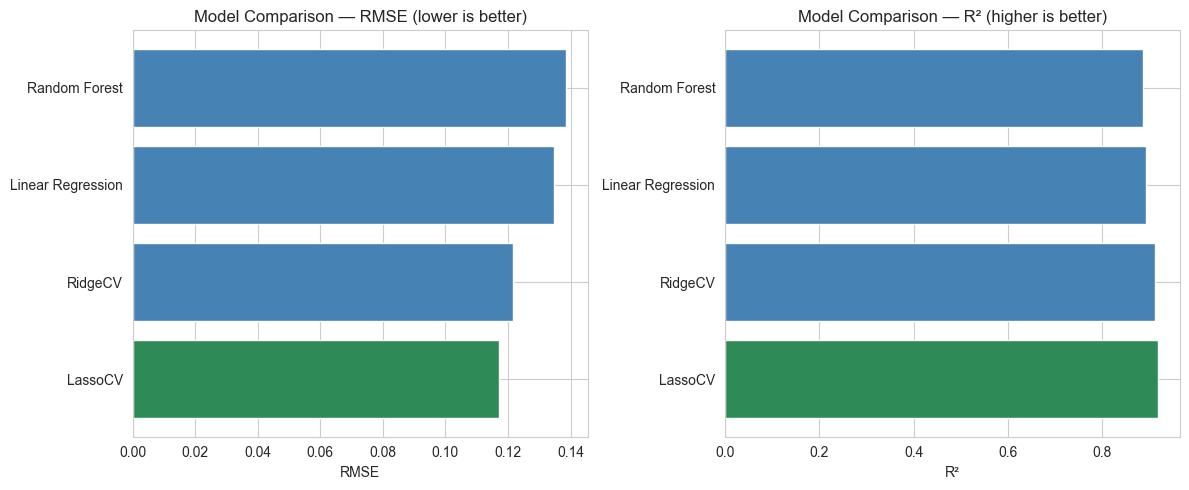

In [14]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'RidgeCV', 'LassoCV', 'Random Forest'],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, rf_rmse],
    'R²': [lr_r2, ridge_r2, lasso_r2, rf_r2]
}).sort_values('RMSE')

print(results.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['steelblue' if m != 'LassoCV' else 'seagreen' for m in results['Model']]

axes[0].barh(results['Model'], results['RMSE'], color=colors, edgecolor='white')
axes[0].set_title('Model Comparison — RMSE (lower is better)')
axes[0].set_xlabel('RMSE')

axes[1].barh(results['Model'], results['R²'], color=colors, edgecolor='white')
axes[1].set_title('Model Comparison — R² (higher is better)')
axes[1].set_xlabel('R²')

plt.tight_layout()
plt.show()

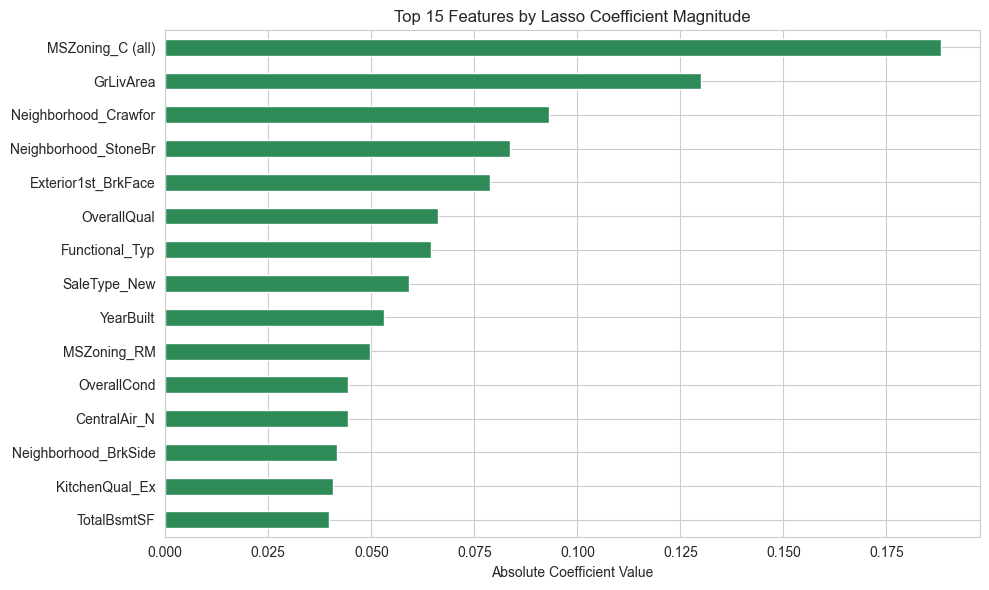


Features zeroed out by Lasso: 184
Features retained: 96


In [15]:
# Get feature names after one-hot encoding
ohe_feature_names = (
    lasso_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
    .tolist()
)

all_feature_names = numeric_cols + ohe_feature_names

# Extract Lasso coefficients
lasso_coefs = pd.Series(
    lasso_pipeline.named_steps['model'].coef_,
    index=all_feature_names
)

# Top 15 by absolute value — non-zero only
top_features = (
    lasso_coefs[lasso_coefs != 0]
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='seagreen', edgecolor='white')
plt.title('Top 15 Features by Lasso Coefficient Magnitude')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

print(f"\nFeatures zeroed out by Lasso: {(lasso_coefs == 0).sum()}")
print(f"Features retained: {(lasso_coefs != 0).sum()}")

In [16]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(lasso_pipeline, '../models/best_model.pkl')
print("Best model saved to models/best_model.pkl ✓")

Best model saved to models/best_model.pkl ✓


## Results Summary

| Model | RMSE | R² |
|---|---|---|
| LassoCV | 0.1172 | 0.9186 |
| RidgeCV | 0.1217 | 0.9122 |
| Linear Regression | 0.1348 | 0.8923 |
| Random Forest | 0.1385 | 0.8862 |

**Selected model: LassoCV** (alpha = 0.000616)

All metrics computed on a held-out test set (20% of data, never seen during training).
Target variable is log-transformed — RMSE is in log(SalePrice) space.

### Key Findings
- Regularization significantly outperformed plain Linear Regression
- LassoCV outperformed Random Forest, indicating the relationship between
  features and price is largely linear after proper encoding and feature engineering
- Lasso zeroed out irrelevant features automatically, performing built-in
  feature selection
- Top predictors: MSZoning, GrLivArea, Neighborhood, OverallQual, YearBuilt